# Product Clustering using K-Means

## Tujuan

Notebook ini bertujuan untuk mengelompokkan produk berdasarkan karakteristik numeriknya menggunakan algoritma K-Means Clustering.

Variabel yang digunakan meliputi:

- Harga rata-rata
- Rating
- Jumlah review
- Jumlah penjualan
- Jumlah followers toko

Hasil clustering diharapkan dapat membantu mengidentifikasi kelompok produk dengan karakteristik yang serupa.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/processed/ecommerce.csv")

Feature Selection

In [2]:
features = [

    "price_avg",

    "rating",

    "review_count",

    "sold",

    "seller_followers"

]

X = df[features].fillna(0)

## Feature Scaling

Karena setiap variabel memiliki satuan yang berbeda, dilakukan proses standardisasi menggunakan StandardScaler agar seluruh fitur memiliki skala yang sebanding.

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Menentukan Jumlah Cluster

Metode Elbow digunakan untuk menentukan jumlah cluster terbaik berdasarkan nilai inertia.

In [4]:
inertia = []

K = range(1,11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

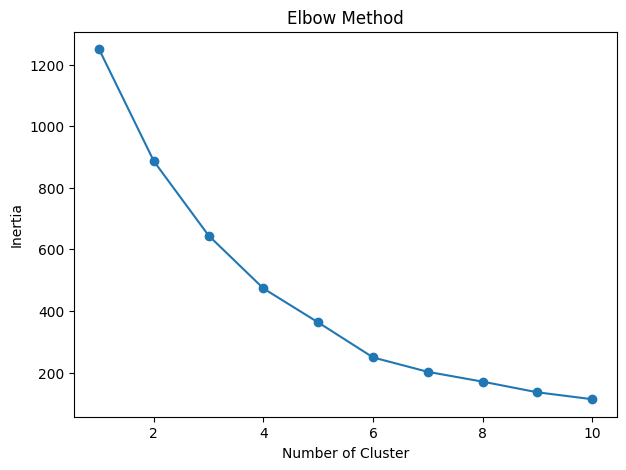

In [5]:
plt.figure(figsize=(7,5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Cluster")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

Training KMeans

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

In [7]:
df["cluster"].value_counts()

cluster
1    224
2     21
0      5
Name: count, dtype: int64

Visualisasi Cluster

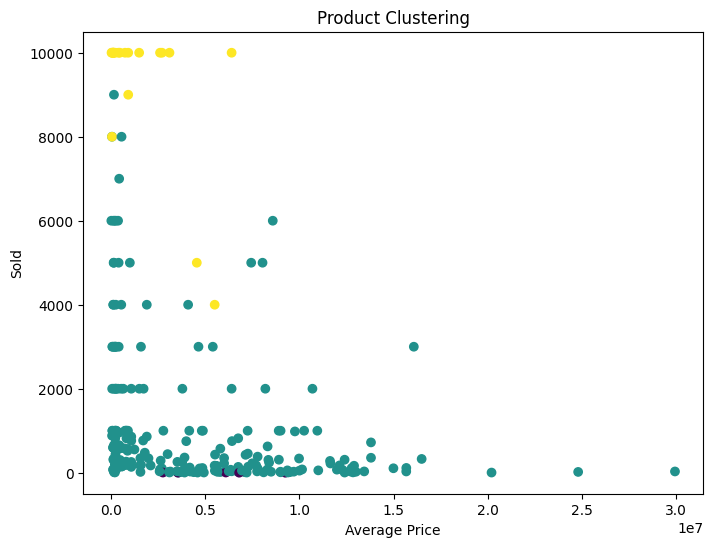

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["price_avg"],
    df["sold"],
    c=df["cluster"]
)

plt.xlabel("Average Price")

plt.ylabel("Sold")

plt.title("Product Clustering")

plt.show()

## Analisis Cluster

Tahapan berikut digunakan untuk melihat karakteristik masing-masing cluster berdasarkan nilai rata-rata setiap fitur.

In [9]:
cluster_summary = df.groupby("cluster")[

    [
        "price_avg",
        "rating",
        "review_count",
        "sold",
        "seller_followers"
    ]

].mean()

cluster_summary

,price_avg,rating,review_count,sold,seller_followers
cluster,,,,,
0,5.687600e+06,NaN,0.000000,2.000000,1.098920e+04
1,4.427654e+06,4.886161,492.383929,1100.464286,1.487300e+05
2,1.459778e+06,4.880952,15580.952381,9333.333333,1.601310e+06


Visualisasi Cluster Summary

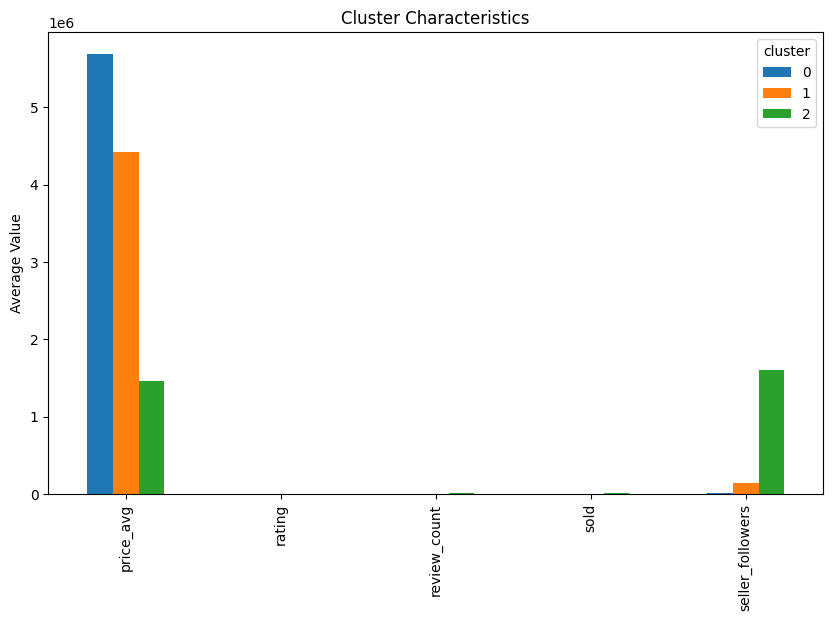

In [10]:
cluster_summary.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Cluster Characteristics")

plt.ylabel("Average Value")

plt.show()

Simpan Dataset

In [11]:
df.to_csv(
    "../data/processed/ecommerce_cluster.csv",
    index=False
)